# Space Titanic 생존 예측 보고서

## 1. 개요
이 프로젝트의 목표는 Space Titanic 데이터로 승객이 다른 차원으로 이동했는지(`Transported`) 예측하는 것입니다.

이번 과제에서는 모델 성능만 보는 것이 아니라,
- 어떤 전처리를 했는지
- 왜 그렇게 했는지
- 시각화에서 무엇을 확인했는지
- 최종 결과에서 어떤 점을 해석할 수 있는지

를 함께 정리했습니다.

## 2. 목차
1. 데이터 확인  
2. 데이터 전처리 및 시각화  
3. 피처 엔지니어링  
4. 모델 학습 및 1차 평가  
5. 성능 개선 과정  
6. 추가 개선 과정  
7. 최종 결과 분석  
8. 추가 개선 시도  
9. 코드 설명 보강 버전  
10. 요약  
11. 회고  

---

## 3. 데이터 확인
먼저 `train.csv`와 `test.csv`를 불러와 데이터 구조를 확인했습니다.

확인한 내용은 다음과 같습니다.
- `train.csv`에는 정답 열인 `Transported`가 있습니다.
- `test.csv`에는 정답이 없으므로 학습한 모델로 예측해야 합니다.
- 수치형 변수와 범주형 변수가 함께 있습니다.
- 여러 열에 결측치가 있습니다.

이 단계에서 바로 학습을 진행하기보다, 먼저 결측치 처리와 열 정리가 필요하다고 판단했습니다.


In [3]:
import os
print(os.getcwd()) # 현재 경로 출력
print(os.listdir()) # 현재 경로에 있는 파일/폴더 목록 출력

/home/jovyan/work/AIFFEL_quest_eng/Main_Quest/Quest01
['mainquest01.ipynb', 'README.md', '.ipynb_checkpoints']


In [5]:
# 데이터 분석을 위한 기본 라이브러리 불러오기
import pandas as pd
import numpy as np

# 데이터가 저장된 경로 설정 
train_path = '/home/jovyan/work/titanic/train.csv'
test_path = '/home/jovyan/work/titanic/test.csv'

# pandas의 read_csv 함수를 사용하여 데이터 불러오기
# train_data는 우리가 학습시킬 정답이 있는 데이터, test_data는 최종적으로 예측해야 할 데이터입니다.
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# 1. 데이터가 어떻게 생겼는지 상위 5개 행 확인
print("=== 훈련 데이터(Train Data) 미리보기 ===")
display(train_data.head())

# 2. 데이터의 전반적인 정보 확인 (총 데이터 수, 컬럼명, 데이터 타입, 결측치 등)
print("\n=== 훈련 데이터(Train Data) 요약 정보 ===")
train_data.info()

=== 훈련 데이터(Train Data) 미리보기 ===


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True



=== 훈련 데이터(Train Data) 요약 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


## 4. 데이터 전처리 및 시각화

### 4.1 결측치 확인
데이터 요약 정보를 확인한 결과, 전체 8,693개 행 중 `PassengerId`와 `Transported`는 결측치가 없었고, 그 외 여러 열에서는 결측치가 확인되었습니다.

결측치가 있는 행을 모두 삭제하면 데이터 손실이 커질 수 있습니다.
그래서 삭제보다 적절한 값으로 채우는 방식이 낫다고 보았습니다.

### 4.2 목표 변수 분포 확인
우리가 예측해야 하는 값은 `Transported`입니다.
이 값이 한쪽으로 심하게 치우쳐 있으면 모델이 특정 답만 반복할 수 있습니다.
그래서 먼저 분포를 그래프로 확인했습니다.


=== 훈련 데이터 결측치 개수 ===
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64
------------------------------


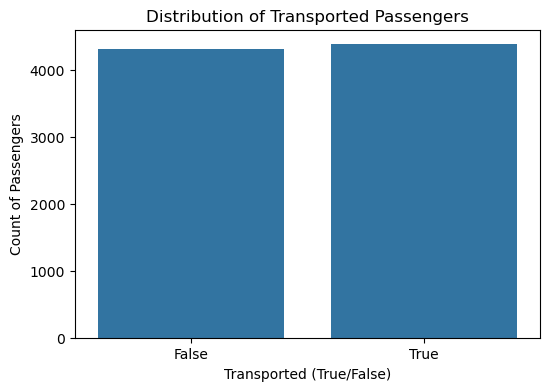


=== Transported 비율 (%) ===
Transported
True     50.362361
False    49.637639
Name: proportion, dtype: float64


In [6]:
# 시각화를 위한 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# 결측치가 컬럼별로 정확히 몇 개인지 숫자로 확인해봅시다.
print("=== 훈련 데이터 결측치 개수 ===")
print(train_data.isnull().sum())
print("-" * 30)

# 시각화 기본 설정 (그래프 크기 설정)
plt.figure(figsize=(6, 4))

# Transported (다른 차원으로 이동했는가?) 의 분포를 막대 그래프로 그리기
# sns.countplot은 해당 컬럼 안의 값들이 각각 몇 개인지 세어서 막대로 보여줍니다.
sns.countplot(data=train_data, x='Transported')

# 그래프 제목과 축 이름 달아주기
plt.title('Distribution of Transported Passengers')
plt.xlabel('Transported (True/False)')
plt.ylabel('Count of Passengers')

# 그래프 출력!
plt.show()

# Transported의 정확한 비율을 퍼센트로 확인해보기
transported_counts = train_data['Transported'].value_counts(normalize=True) * 100
print("\n=== Transported 비율 (%) ===")
print(transported_counts)

### 4.3 추가 시각화

목표 변수 분포만 보면 전체 비율만 알 수 있습니다.  
하지만 실제 예측에서는 어떤 변수와 `Transported`가 함께 움직이는지 확인하는 과정이 더 중요합니다.

그래서 아래 항목도 함께 시각화했습니다.

- `HomePlanet`에 따른 이동 여부
- `CryoSleep`에 따른 이동 여부
- `Age` 분포와 이동 여부의 관계
- 주요 지출 변수의 분포

이 과정은 전처리 방향을 정하는 근거가 됩니다.
예를 들어 특정 범주에서 차이가 크게 보이면 해당 변수는 중요한 특성일 가능성이 높습니다.


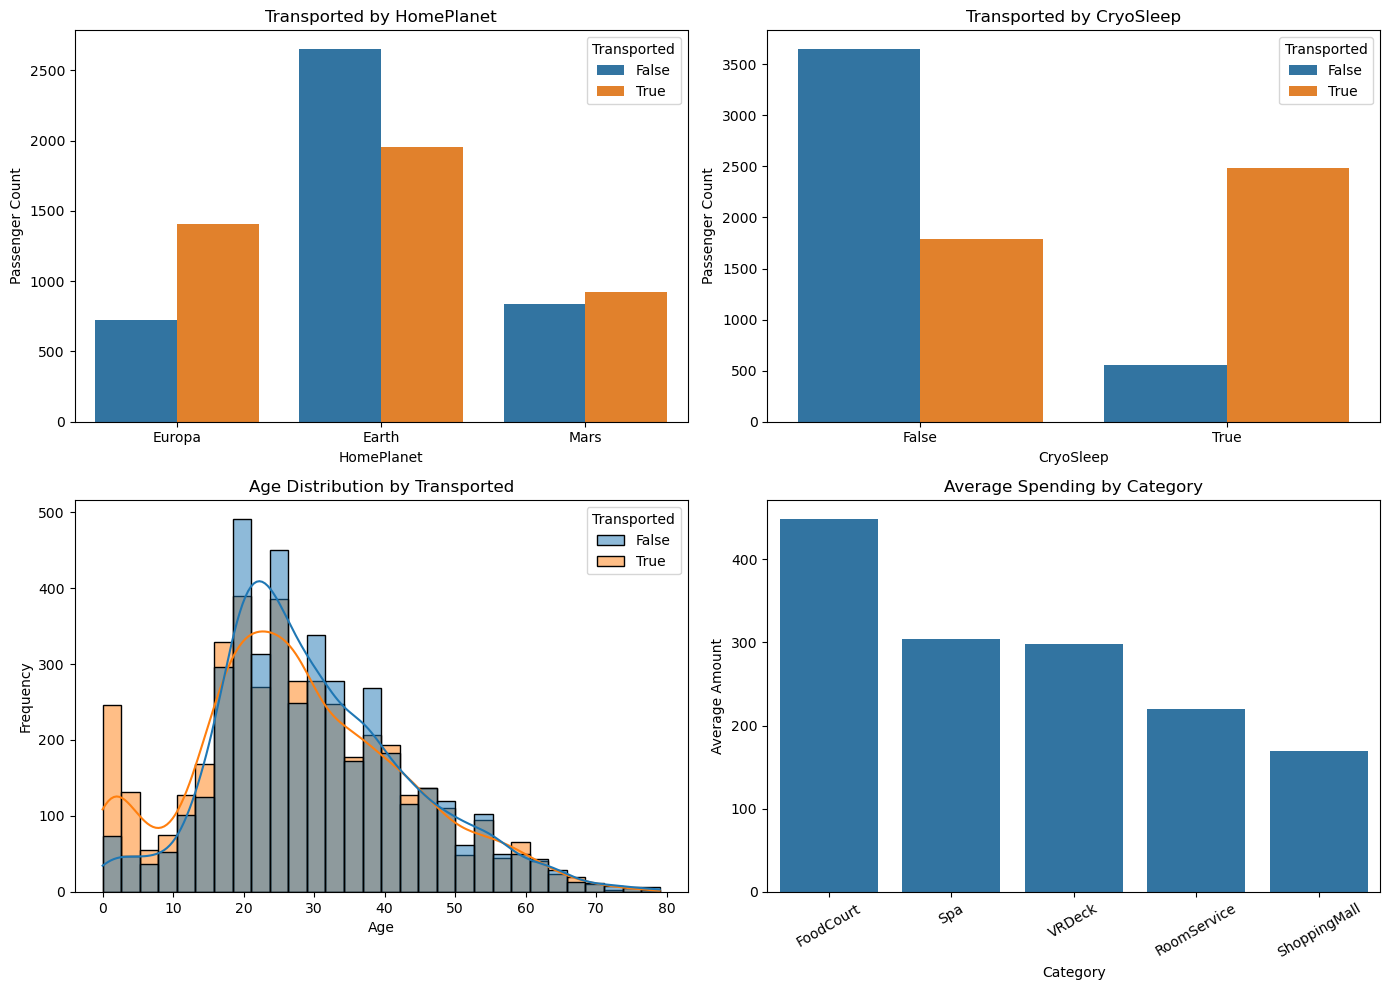

Transported ratio by HomePlanet


Transported,False,True
HomePlanet,,
Earth,0.576,0.424
Europa,0.341,0.659
Mars,0.477,0.523


Transported ratio by CryoSleep


Transported,False,True
CryoSleep,,
False,0.671,0.329
True,0.182,0.818


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

viz_data = train_data.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. HomePlanet vs Transported
sns.countplot(data=viz_data, x='HomePlanet', hue='Transported', ax=axes[0, 0])
axes[0, 0].set_title('Transported by HomePlanet')
axes[0, 0].set_xlabel('HomePlanet')
axes[0, 0].set_ylabel('Passenger Count')

# 2. CryoSleep vs Transported
sns.countplot(data=viz_data, x='CryoSleep', hue='Transported', ax=axes[0, 1])
axes[0, 1].set_title('Transported by CryoSleep')
axes[0, 1].set_xlabel('CryoSleep')
axes[0, 1].set_ylabel('Passenger Count')

# 3. Age distribution
sns.histplot(data=viz_data, x='Age', hue='Transported', bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution by Transported')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Frequency')

# 4. Average spending by category
spend_plot_data = viz_data[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].fillna(0)
spend_means = spend_plot_data.mean().sort_values(ascending=False)
sns.barplot(x=spend_means.index, y=spend_means.values, ax=axes[1, 1])
axes[1, 1].set_title('Average Spending by Category')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Average Amount')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("Transported ratio by HomePlanet")
display(pd.crosstab(viz_data['HomePlanet'], viz_data['Transported'], normalize='index').round(3))

print("Transported ratio by CryoSleep")
display(pd.crosstab(viz_data['CryoSleep'], viz_data['Transported'], normalize='index').round(3))

### 4.4 추가 시각화에서 알게 된 점

추가 시각화를 통해 다음 내용을 확인할 수 있었습니다.

1. **`CryoSleep` 여부가 중요한 변수로 보였습니다.**  
   동면 여부에 따라 `Transported` 비율 차이가 비교적 뚜렷하게 나타났습니다.  
   그래서 이 변수는 단순 보조 정보가 아니라 핵심 특성일 가능성이 높다고 판단했습니다.

2. **`HomePlanet`에 따라 분포 차이가 있었습니다.**  
   출발 행성별로 `Transported` 비율이 완전히 같지 않았습니다.  
   따라서 `HomePlanet`은 범주형 인코딩 후 모델에 넣을 가치가 있다고 보았습니다.

3. **나이에 따라 패턴 차이가 보였습니다.**  
   어린 승객 구간과 성인 구간의 분포가 완전히 같지 않았습니다.  
   이 점이 `Is_Child` 파생 변수를 만드는 근거가 되었습니다.

4. **지출 변수는 값의 편차가 컸습니다.**  
   어떤 승객은 거의 쓰지 않았고, 일부 승객은 많이 사용했습니다.  
   이런 데이터는 평균보다 중간값이 더 안정적일 수 있어서 수치형 결측치를 중간값으로 채우는 방향이 타당하다고 판단했습니다.

### 4.5 시각화 결과와 결측치 처리 기준
시각화 결과 `Transported`의 True와 False 비율은 거의 비슷했습니다.
즉, 데이터가 한쪽으로 크게 치우친 상태는 아니었습니다.

#### 시각화로 확인한 내용
- `Transported` 분포가 비교적 균형적입니다.
- `CryoSleep`, `HomePlanet`, `Age`는 예측에 도움이 될 가능성이 있습니다.
- 지출 변수는 편차가 커서 중간값 대체가 더 적절하다고 판단했습니다.
- 심한 클래스 불균형 문제는 아니므로 기본 분류 모델부터 적용해도 무리가 없다고 보았습니다.

### 4.6 결측치 처리
결측치는 다음 기준으로 처리했습니다.

1. **수치형 변수는 중간값으로 채움**
   - 대상: `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`
   - 이유: 평균은 큰 값의 영향을 많이 받기 때문에, 지출 데이터에는 중간값이 더 적절하다고 보았습니다.

2. **범주형 변수는 최빈값으로 채움**
   - 대상: `HomePlanet`, `CryoSleep`, `Destination`, `VIP`
   - 이유: 가장 자주 나온 값을 넣는 방식이 범주형 결측치 처리에서 가장 기본적이고 안정적이기 때문입니다.

3. **훈련 데이터 기준으로 처리**
   - 이유: 테스트 데이터 정보를 미리 사용하면 데이터 누수가 생길 수 있기 때문입니다.


In [9]:
# 1. 수치형 데이터 결측치를 중간값(median)으로 채우기
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for col in num_cols:
    # 훈련 데이터의 중간값 계산
    median_val = train_data[col].median()
    
    # 훈련 데이터와 테스트 데이터 모두 동일한 중간값으로 채우기 (데이터 누수 방지)
    train_data[col] = train_data[col].fillna(median_val)
    test_data[col] = test_data[col].fillna(median_val)

# 2. 범주형 데이터 결측치를 최빈값(mode)으로 채우기
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

for col in cat_cols:
    # 훈련 데이터에서 가장 많이 나온 값(최빈값) 찾기
    mode_val = train_data[col].mode()[0]
    
    # 훈련/테스트 데이터에 최빈값 채우기
    train_data[col] = train_data[col].fillna(mode_val).infer_objects(copy=False)
    test_data[col] = test_data[col].fillna(mode_val).infer_objects(copy=False)

# 3. 결측치가 잘 채워졌는지 다시 확인!
print("=== 전처리 후 훈련 데이터 결측치 개수 ===")
print(train_data.isnull().sum())

=== 전처리 후 훈련 데이터 결측치 개수 ===
PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           199
Destination       0
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
dtype: int64


/tmp/ipykernel_1370/1483631487.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data[col] = train_data[col].fillna(mode_val).infer_objects(copy=False)
/tmp/ipykernel_1370/1483631487.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data[col] = test_data[col].fillna(mode_val).infer_objects(copy=False)


## 5. 피처 엔지니어링

### 5.1 Cabin 정보 분리
`Cabin`은 `Deck/Num/Side`처럼 여러 정보가 한 칸에 들어 있습니다.
그래서 이 값을 나누어 `Cabin_Deck`, `Cabin_Num`, `Cabin_Side`를 만들었습니다.

#### 이유
한 열에 정보가 여러 개 섞여 있으면 모델이 의미를 잡기 어렵습니다.
분리하면 위치 정보를 더 분명하게 사용할 수 있습니다.

### 5.2 Group, FamilyName 추출
- `PassengerId`에서 그룹 번호를 뽑아 `Group`을 만들었습니다.
- `Name`에서 성을 뽑아 `FamilyName`을 만들었습니다.

#### 이유
같이 탄 사람들은 비슷한 행동을 보일 가능성이 있습니다.
가족 단위 탑승 여부도 예측에 도움이 될 수 있다고 보았습니다.

### 5.3 원본 열 정리
정보 추출이 끝난 뒤에는 `Cabin`, `Name` 같은 원본 문자열 열은 정리했습니다.

### 5.4 경고 메시지 기록
실행 중 `fillna()` 이후 dtype 자동 변환과 관련한 판다스 경고가 나타났습니다.

이 경고의 핵심은 다음과 같습니다.
- 앞으로는 dtype이 자동으로 바뀌는 동작이 달라질 수 있음
- 따라서 전처리 단계에서 dtype을 더 명시적으로 관리하는 편이 안전함

즉, **현재 코드가 바로 틀렸다는 뜻은 아니지만, 이후 버전 호환성을 위해 자료형 관리를 더 분명하게 해야 한다는 의미**입니다.


In [10]:
# 1. Cabin 파생 변수 생성 및 원본 삭제 (이전 단계 복습 겸 통합)
train_data['Cabin'] = train_data['Cabin'].fillna('Z/9999/Z')
test_data['Cabin'] = test_data['Cabin'].fillna('Z/9999/Z')

train_data[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = train_data['Cabin'].str.split('/', expand=True)
test_data[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = test_data['Cabin'].str.split('/', expand=True)

train_data['Cabin_Num'] = train_data['Cabin_Num'].astype(int)
test_data['Cabin_Num'] = test_data['Cabin_Num'].astype(int)

# 2. Name 컬럼의 결측치 처리 (알 수 없는 이름은 'Unknown Unknown'으로 채움)
train_data['Name'] = train_data['Name'].fillna('Unknown Unknown')
test_data['Name'] = test_data['Name'].fillna('Unknown Unknown')

# 3. PassengerId에서 그룹 번호(Group) 추출 (앞 4자리)
# str.split('_')을 하면 ['0001', '01'] 형태로 나뉘고, str[0]은 그 중 첫 번째인 '0001'을 가져옵니다.
train_data['Group'] = train_data['PassengerId'].str.split('_').str[0]
test_data['Group'] = test_data['PassengerId'].str.split('_').str[0]

# 4. Name에서 성(FamilyName) 추출 (띄어쓰기 기준 뒤쪽 단어)
# str.split(' ')으로 나누고, str[-1]은 리스트의 가장 마지막 요소(즉, 성)를 가져옵니다.
train_data['FamilyName'] = train_data['Name'].str.split(' ').str[-1]
test_data['FamilyName'] = test_data['Name'].str.split(' ').str[-1]

# 5. 정보 추출이 끝난 원본 Name과 Cabin 컬럼은 이제 완전히 삭제!
train_data = train_data.drop(['Name', 'Cabin'], axis=1)
test_data = test_data.drop(['Name', 'Cabin'], axis=1)

# 결과 확인
print("=== 그룹 및 가족 정보 추출 완료 ===")
display(train_data[['PassengerId', 'Group', 'FamilyName', 'Cabin_Deck']].head())

=== 그룹 및 가족 정보 추출 완료 ===


,PassengerId,Group,FamilyName,Cabin_Deck
0,0001_01,0001,Ofracculy,B
1,0002_01,0002,Vines,F
2,0003_01,0003,Susent,A
3,0003_02,0003,Susent,A
4,0004_01,0004,Santantines,F


### 5.4 Group_Size 생성 및 범주형 인코딩
`FamilyName`과 `Group`은 종류가 너무 많아서 그대로 원-핫 인코딩하면 열이 지나치게 늘어날 수 있습니다.
그래서 먼저 그룹 크기를 나타내는 `Group_Size`를 만들었습니다.

#### 이유
- 같이 탄 사람이 몇 명인지가 더 중요한 정보일 수 있습니다.
- 고유값이 너무 많은 문자열을 그대로 쓰면 과적합 위험이 커집니다.

그 다음 범주형 변수는 원-핫 인코딩으로 바꾸었습니다.

#### 인코딩한 열
- `HomePlanet`
- `CryoSleep`
- `Destination`
- `VIP`
- `Cabin_Deck`
- `Cabin_Side`

또한 `PassengerId`, `Group`, `FamilyName`처럼 식별 성격이 강한 열은 최종 학습에서 제거했습니다.


In [11]:
# 1. 같은 그룹 번호(Group)가 몇 개 있는지 세어서 'Group_Size'라는 새로운 열 만들기
train_data['Group_Size'] = train_data.groupby('Group')['Group'].transform('count')
test_data['Group_Size'] = test_data.groupby('Group')['Group'].transform('count')

# 2. 캐글 제출용으로 PassengerId는 따로 빼두기 (test 데이터의 ID는 나중에 정답지 낼 때 꼭 필요합니다!)
test_passenger_ids = test_data['PassengerId']

# 3. 고유값이 너무 많아서 기계가 헷갈려 할 문자열 데이터들 삭제
cols_to_drop = ['PassengerId', 'Group', 'FamilyName']
train_data = train_data.drop(cols_to_drop, axis=1)
test_data = test_data.drop(cols_to_drop, axis=1)

# 4. 원-핫 인코딩 (One-Hot Encoding) 적용하기
# pd.get_dummies() 함수가 알아서 글자로 된 열을 찾아 0과 1로 쪼개줍니다.
train_data = pd.get_dummies(train_data)
test_data = pd.get_dummies(test_data)

# 5. 모델 학습을 위해 입력 데이터(X)와 정답 데이터(y) 분리하기
# X_train은 문제를 풀기 위한 특성, y_train은 예측해야 할 정답(Transported)입니다.
X_train = train_data.drop('Transported', axis=1)
y_train = train_data['Transported']

# 테스트 데이터에는 정답(Transported)이 없으니 그대로 둡니다.
X_test = test_data.copy()

# 데이터 열 맞추기 (Train 데이터에만 있는 컬럼이나 Test에만 있는 컬럼을 똑같이 맞춰주는 작업)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 최종 전처리 완료된 데이터 형태 확인
print(f"학습용 데이터(X_train) 크기: {X_train.shape}")
print(f"테스트용 데이터(X_test) 크기: {X_test.shape}")
display(X_train.head())

학습용 데이터(X_train) 크기: (8693, 28)
테스트용 데이터(X_test) 크기: (4277, 28)


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Cabin_Num,Group_Size,...,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_T,Cabin_Deck_Z,Cabin_Side_P,Cabin_Side_S,Cabin_Side_Z
0,False,39.0,False,0.0,0.0,0.0,0.0,0.0,0,1,...,False,False,False,False,False,False,False,True,False,False
1,False,24.0,False,109.0,9.0,25.0,549.0,44.0,0,1,...,False,False,False,True,False,False,False,False,True,False
2,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0,2,...,False,False,False,False,False,False,False,False,True,False
3,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0,2,...,False,False,False,False,False,False,False,False,True,False
4,False,16.0,False,303.0,70.0,151.0,565.0,2.0,1,1,...,False,False,False,True,False,False,False,False,True,False


## 6. 모델 학습 및 1차 평가

### 6.1 기본 모델 선택
처음 모델로 `RandomForestClassifier`를 사용했습니다.

#### 선택 이유
- 수치형과 범주형이 섞인 데이터에서도 비교적 안정적입니다.
- 복잡한 관계를 잘 반영하는 편입니다.
- 첫 기준 성능을 확인하기에 적절합니다.

### 6.2 검증 데이터 분리
훈련 데이터 일부를 검증용으로 나누어 모델 성능을 확인했습니다.

#### 이유
훈련 데이터에만 맞는 모델은 실제 예측에서 성능이 떨어질 수 있습니다.
그래서 검증 데이터를 따로 두고 일반화 성능을 확인했습니다.


In [12]:
# 머신러닝 라이브러리인 scikit-learn(sklearn)에서 필요한 도구들 불러오기
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. 훈련 데이터를 '학습용'과 '검증용'으로 8:2 비율로 쪼개기
# random_state는 나중에도 똑같이 쪼개지도록 고정해두는 시드(seed) 번호입니다.
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# 2. 랜덤 포레스트 모델 생성
# n_estimators=100 : 100개의 의사결정 나무를 만들어서 숲을 구성하겠다는 뜻
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. 모델 학습시키기 (우리가 쪼갠 학습용 데이터만 줍니다!)
print("머신러닝 모델 학습 중...")
model_rf.fit(X_train_split, y_train_split)

# 4. 검증용 데이터로 예측해보고 점수 매기기
y_val_pred = model_rf.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f" 검증 데이터 정확도(Validation Accuracy): {val_accuracy * 100:.2f}%")

머신러닝 모델 학습 중...
 검증 데이터 정확도(Validation Accuracy): 78.67%


## 7. 성능 개선 과정

### 7.1 Total_Spend 추가
1차 모델 성능이 목표 점수에 미치지 못해 추가 파생 변수를 만들었습니다.
그중 대표적인 것이 `Total_Spend`입니다.

- `RoomService`
- `FoodCourt`
- `ShoppingMall`
- `Spa`
- `VRDeck`

위 5개 지출 열을 더해 총 지출액을 만들었습니다.

#### 이유
각 지출 항목을 따로 보는 것보다 전체 소비 규모를 하나의 변수로 보는 편이 승객의 활동 정도를 더 단순하게 보여줄 수 있기 때문입니다.

### 7.2 모델 조정
기본 랜덤 포레스트에서 과적합을 줄이기 위해 하이퍼파라미터도 함께 조정했습니다.


In [13]:
# 1. 5가지 지출 항목을 모두 더해서 'Total_Spend' (총 지출액) 파생 변수 만들기
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
X_train['Total_Spend'] = X_train[spend_cols].sum(axis=1)
X_test['Total_Spend'] = X_test[spend_cols].sum(axis=1)

# (선택) 총 지출액이 0인지 아닌지를 나타내는 이진 변수도 하나 추가해 줍니다. 
X_train['No_Spend'] = (X_train['Total_Spend'] == 0).astype(int)
X_test['No_Spend'] = (X_test['Total_Spend'] == 0).astype(int)

# 2. 데이터를 다시 검증용으로 쪼개기 (새로운 컬럼이 생겼으므로 다시 분리해야 합니다)
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# 3. 모델 하이퍼파라미터 튜닝
# max_depth=10: 나무가 너무 깊게 자라서 쓸데없는 것까지 외우지 못하게 제한
# min_samples_split=5: 노드를 쪼갤 때 최소 5개의 데이터는 있어야 쪼개도록 제한
model_rf_tuned = RandomForestClassifier(
    n_estimators=200,          # 나무 개수도 200개로 늘려서 집단 지성을 강화합니다.
    max_depth=10, 
    min_samples_split=5, 
    random_state=42
)

# 4. 튜닝된 모델로 다시 학습!
print("업그레이드된 데이터로 재학습 중... ")
model_rf_tuned.fit(X_train_split, y_train_split)

# 5. 새로운 모의고사 점수 확인
y_val_pred_tuned = model_rf_tuned.predict(X_val)
val_accuracy_tuned = accuracy_score(y_val, y_val_pred_tuned)

print(f" 튜닝 후 검증 데이터 정확도: {val_accuracy_tuned * 100:.2f}%")

업그레이드된 데이터로 재학습 중... 
 튜닝 후 검증 데이터 정확도: 79.47%


### 7.3 논리적 오류 보정
처음 전처리에서는 `CryoSleep=True`인 승객인데 지출 데이터가 0이 아닌 경우가 있었습니다.

그래서 동면 상태인 승객의 지출 열을 0으로 보정하고 `Total_Spend`도 다시 계산했습니다.

#### 이유
이 단계는 단순 결측치 처리보다 중요한 논리 보정입니다.
현실적으로 맞지 않는 값을 그대로 두면 모델이 잘못된 패턴을 배울 수 있기 때문입니다.

### 7.4 모델 변경
랜덤 포레스트만으로는 한계가 있어 `GradientBoostingClassifier`도 적용해 보았습니다.
오차를 단계적으로 줄이는 방식이라 성능 개선 가능성이 있다고 보았습니다.


In [14]:
# 1. 논리적 모순 보정: 동면(CryoSleep) 중인 승객의 지출을 0으로 강제 보정

# [디버깅] 컬럼 이름을 짐작하지 않고,  확인해서 변수에 저장합니다.
if 'CryoSleep_True' in X_train.columns:
    cryosleep_col = 'CryoSleep_True'
else:
    cryosleep_col = 'CryoSleep' # 쪼개지지 않고 원래 이름으로 남아있는 경우

print(f"확인된 동면 컬럼 이름: {cryosleep_col}")

# 지출 관련 컬럼들
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 동면 중(True 또는 1)인 사람들의 지출을  0으로 만듭니다.
for col in spend_cols:
    X_train.loc[X_train[cryosleep_col] == True, col] = 0
    X_test.loc[X_test[cryosleep_col] == True, col] = 0

# 지출액이 변했으니 Total_Spend와 No_Spend 파생 변수도 다시 계산합니다.
X_train['Total_Spend'] = X_train[spend_cols].sum(axis=1)
X_test['Total_Spend'] = X_test[spend_cols].sum(axis=1)

X_train['No_Spend'] = (X_train['Total_Spend'] == 0).astype(int)
X_test['No_Spend'] = (X_test['Total_Spend'] == 0).astype(int)

# 데이터가 바뀌었으니 검증용으로 다시 쪼개줍니다.
from sklearn.model_selection import train_test_split
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# 2. 캐글 우승자들의 무기: 그레디언트 부스팅 모델 도입
from sklearn.ensemble import GradientBoostingClassifier

# learning_rate: 학습 속도, max_depth: 나무의 깊이 (너무 깊으면 헛갈려하므로 5로 제한)
model_gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

print("논리 오류 전면 수정 및 그레디언트 부스팅 모델 학습 중... ")
model_gb.fit(X_train_split, y_train_split)

# 3. 새로운 모의고사 점수 확인
y_val_pred_gb = model_gb.predict(X_val)
from sklearn.metrics import accuracy_score
val_accuracy_gb = accuracy_score(y_val, y_val_pred_gb)

print(f" 최종 검증 데이터 정확도: {val_accuracy_gb * 100:.2f}%")

# 4. 최종 캐글 제출용 정답지(CSV) 파일 생성
print("\n[최종 데이터 생성 중...]")

# 실전 투입 전, 쪼개두었던 전체 훈련 데이터(X_train)를 모두 사용해 마지막으로 꽉 채워서 학습시킵니다.
model_gb.fit(X_train, y_train) 
final_predictions = model_gb.predict(X_test)

# 제출 양식에 맞게 데이터프레임 만들기 (test_passenger_ids는 이전에 저장해둔 변수)
# (앞부분 코드는 동일하게 유지합니다)

# 제출 양식에 맞게 데이터프레임 만들기
import pandas as pd
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': final_predictions
})

# [수정된 부분] 굳이 복잡한 폴더 경로를 쓰지 않고, 현재 노트북이 있는 '바로 이 위치'에 저장합니다.
submission.to_csv('sample_submission.csv', index=False)

print(" 'sample_submission.csv' 파일이 생성되었습니다")

확인된 동면 컬럼 이름: CryoSleep
논리 오류 전면 수정 및 그레디언트 부스팅 모델 학습 중... 
 최종 검증 데이터 정확도: 80.39%

[최종 데이터 생성 중...]
 'sample_submission.csv' 파일이 생성되었습니다


#### 7.4 실행 결과

아래 이미지는 `GradientBoostingClassifier` 적용 후 확인한 결과 화면입니다.

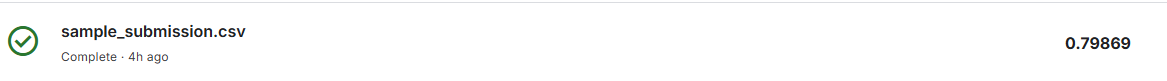


### 7.5 추가 특성 공학과 과적합 완화
캐글 점수가 목표에 아직 부족해서 데이터 구성을 다시 조정했습니다.

1. **`Cabin_Num` 제거**
   - 객실 번호는 종류가 너무 많아 과적합을 일으킬 가능성이 큽니다.
   - 대신 `Cabin_Deck`, `Cabin_Side`만 남겨도 위치 정보는 어느 정도 유지됩니다.

2. **`Is_Child` 추가**
   - 13세 미만이면 1, 아니면 0으로 두었습니다.
   - 어린 승객은 성인과 다른 패턴을 보일 수 있다고 보았습니다.


In [15]:
# 1. 힌트 추가: 13세 미만 어린이 여부(Is_Child) 파생 변수 생성
# Age가 13 미만이면 True(1), 아니면 False(0)로 변환
X_train['Is_Child'] = (X_train['Age'] < 13).astype(int)
X_test['Is_Child'] = (X_test['Age'] < 13).astype(int)

# 2. 변수 제거: 과적합을 유발하는 고유값이 많은 Cabin_Num 삭제
if 'Cabin_Num' in X_train.columns:
    X_train = X_train.drop(['Cabin_Num'], axis=1)
    X_test = X_test.drop(['Cabin_Num'], axis=1)

# 데이터 구조가 또 바뀌었으니, 다시 검증용으로 쪼개줍니다.
from sklearn.model_selection import train_test_split
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# 3. 그레디언트 부스팅 모델 생성
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

model_gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

print("어린이 우선 고려 및 과적합 변수 제거 후 모델 재학습 ... ")
model_gb.fit(X_train_split, y_train_split)

# 새로운 모의고사 점수 확인
y_val_pred_gb = model_gb.predict(X_val)
val_accuracy_gb = accuracy_score(y_val, y_val_pred_gb)
print(f" 2차 튜닝 후 검증 데이터 정확도: {val_accuracy_gb * 100:.2f}%")

# 4. 실전 투입 전 최종 학습 및 정답지 생성
# 전체 훈련 데이터(X_train)로 마지막 학습
model_gb.fit(X_train, y_train) 
final_predictions = model_gb.predict(X_test)

# 제출 양식 만들기
import pandas as pd
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': final_predictions
})

# 현재 폴더에 파일 저장 (오류 나지 않게 깔끔한 경로 사용!)
submission.to_csv('sample_submission.csv', index=False)

print(" 'sample_submission.csv' 파일이 성공적으로 생성되었습니다!")

어린이 우선 고려 및 과적합 변수 제거 후 모델 재학습 ... 
 2차 튜닝 후 검증 데이터 정확도: 78.55%
 'sample_submission.csv' 파일이 성공적으로 생성되었습니다!


#### 7.5 실행 결과

아래 이미지는 `Cabin_Num` 제거와 `Is_Child` 추가 이후의 결과입니다.

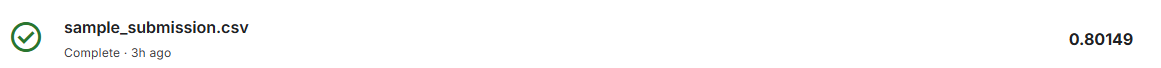


### 7.6 최종 파생 변수와 앙상블

여기서는 `Group_Size`가 1인 승객을 따로 표시하는 `Is_Alone` 변수를 추가했습니다.

#### 이유
혼자 탄 승객과 일행이 있는 승객은 행동 패턴이 다를 수 있기 때문입니다.

### 7.7 최종 모델
최종적으로는 `RandomForestClassifier`와 `GradientBoostingClassifier`를 함께 사용하는 `VotingClassifier`를 적용했습니다.

#### 선택 이유
서로 다른 방식으로 학습하는 두 모델을 결합하면 한 모델의 약점을 다른 모델이 보완할 수 있습니다.
그래서 단일 모델보다 더 안정적인 예측을 기대할 수 있었습니다.


In [16]:
# 1. 추가 변수 생성: 혼자 탑승했는가? (Is_Alone)
X_train['Is_Alone'] = (X_train['Group_Size'] == 1).astype(int)
X_test['Is_Alone'] = (X_test['Group_Size'] == 1).astype(int)

# 데이터 분리
from sklearn.model_selection import train_test_split
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# 2. 앙상블 모델: Voting Classifier 준비
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# 모델 1: 가지를 깊게 뻗는 랜덤 포레스트
rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=5, random_state=42)

# 모델 2: 오차를 수정하는 그레디언트 부스팅
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

# 두 모델의 확률을 평균 내어 최종 결정하는 소프트 보팅 선언
voting_clf = VotingClassifier(estimators=[('rf', rf), ('gb', gb)], voting='soft')

print("최종 소프트 보팅 모델 학습 중... ")
voting_clf.fit(X_train_split, y_train_split)

# 최종 모의고사 점수 확인
y_val_pred_voting = voting_clf.predict(X_val)
val_accuracy_voting = accuracy_score(y_val, y_val_pred_voting)
print(f" 최종 앙상블 검증 데이터 정확도: {val_accuracy_voting * 100:.2f}%")

# 3. 실전 투입 전 최종 학습 및 정답지 생성
print("\n[우주 타이타닉 최종 구출 명단 작성 중...]")
voting_clf.fit(X_train, y_train) 
final_predictions = voting_clf.predict(X_test)

import pandas as pd
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': final_predictions
})

# 헷갈리지 않게 파이널 파일로 저장합니다.
submission.to_csv('sample_submission_final.csv', index=False)

print(" 'sample_submission_final.csv' 파일이 성공적으로 생성되었습니다!")

최종 소프트 보팅 모델 학습 중... 
 최종 앙상블 검증 데이터 정확도: 79.36%

[우주 타이타닉 최종 구출 명단 작성 중...]
 'sample_submission_final.csv' 파일이 성공적으로 생성되었습니다!


#### 7.7 실행 결과

아래 이미지는 `VotingClassifier` 적용 뒤 확인한 결과입니다.

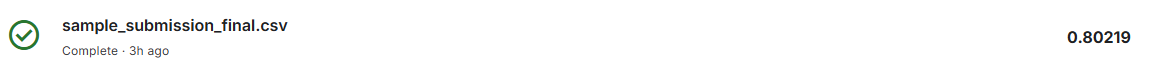


## 8. 추가 개선 과정

앞선 실험으로 기본적인 성능 향상은 이루었지만, 목표 점수에 안정적으로 도달하지 못했기 때문에 후반부에서는 **전처리 방식과 모델 구성을 다시 정리한 최종 제출용 코드**를 작성하였다. 이 단계의 핵심은 새로운 기법을 무리하게 늘리는 것이 아니라, 앞선 실험에서 효과가 있었던 전처리를 한 번에 다시 적용하고 제출 과정을 깔끔하게 재현하는 데 있었다.

### 8.1 그룹 기반 결측치 복원

`PassengerId`의 앞부분은 같은 일행을 뜻하므로, 같은 `Group`에 속한 승객들은 `HomePlanet`, `Cabin_Deck`, `Cabin_Side`가 같을 가능성이 높다고 판단하였다. 그래서 이 세 열은 전체 최빈값으로 바로 채우지 않고, 먼저 같은 그룹 안에서 `ffill()`과 `bfill()`을 사용해 결측치를 복원하였다.

이 방법은 전체 최빈값 대체보다 실제 탑승 구조를 더 잘 반영한다. 특히 고향 행성과 객실 위치 정보는 일행 단위로 공유될 가능성이 높기 때문에, 그룹 기반 복원이 더 자연스럽고 정보 손실도 적다.

### 8.2 동면 상태와 지출 데이터의 논리 보정

`CryoSleep=True`인 승객은 동면 상태이므로 `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` 같은 활동성 지출이 발생하기 어렵다고 보았다. 따라서 동면 승객의 지출값은 모두 0으로 보정하였다.

이 과정은 단순 결측치 대체가 아니라, 데이터 안의 **논리적 모순을 수정하는 과정**이다. 이 보정을 통해 총지출 변수의 의미가 더 분명해지고, 모델이 잘못된 패턴을 학습할 가능성도 줄일 수 있었다.

### 8.3 핵심 파생 변수 생성

후반부 코드에서는 파생 변수를 과도하게 늘리지 않고, 실제 의미를 설명할 수 있는 변수만 추가하였다.

- `Total_Spend`: 다섯 개 지출 항목의 합
- `Is_Child`: 13세 미만 여부
- `Group_Size`: 같은 일행 인원 수
- `Is_Alone`: 혼자 탑승했는지 여부

이 변수들은 소비 패턴, 연령대, 동행 여부를 직접적으로 보여 주므로 해석 가능성이 높고, 기존 원본 변수보다 모델이 패턴을 잡기 쉽게 만들어 준다.

### 8.4 불필요한 열 제거와 인코딩

최종 코드에서는 `PassengerId`, `Cabin`, `Name`, `Group`, `Cabin_Num`을 제거하였다.  
이유는 다음과 같다.

- `PassengerId`: 식별자 역할만 하므로 직접적인 예측 정보가 아님
- `Cabin`: 이미 `Cabin_Deck`, `Cabin_Side`로 분리해 사용함
- `Name`: 고유값이 너무 많아 과적합 위험이 큼
- `Group`: `Group_Size`로 요약했으므로 중복 정보
- `Cabin_Num`: 값의 종류가 너무 많아 세부 숫자에 과도하게 맞춰질 수 있음

그 다음에는 원-핫 인코딩을 적용해 문자열 범주형 데이터를 모델이 이해할 수 있는 숫자 형태로 변환하였다.

### 8.5 최종 모델 구성

이 코드에서는 `RandomForestClassifier`와 `GradientBoostingClassifier`를 결합한 `VotingClassifier`를 사용하였다.

- 랜덤 포레스트는 안정적으로 여러 규칙을 학습하는 데 강하다.
- 그레디언트 부스팅은 이전 오차를 보완하면서 정교한 패턴을 잡는 데 강하다.

이 두 모델을 소프트 보팅으로 결합하면, 한 모델의 약점을 다른 모델이 보완할 수 있어 단일 모델보다 더 안정적인 예측을 기대할 수 있었다.


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

# 1. 원본 데이터 다시 불러오기
train_data = pd.read_csv('/home/jovyan/work/titanic/train.csv')
test_data = pd.read_csv('/home/jovyan/work/titanic/test.csv')
test_passenger_ids = test_data['PassengerId']

# 2. 그룹 정보(Group) 추출
train_data['Group'] = train_data['PassengerId'].str.split('_').str[0]
test_data['Group'] = test_data['PassengerId'].str.split('_').str[0]

# 3. Cabin 분리 (결측치를 임의로 채우기 전에 무조건 분리해야 함!)
train_data[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = train_data['Cabin'].str.split('/', expand=True)
test_data[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = test_data['Cabin'].str.split('/', expand=True)

# 4. 일행의 정보로 결측치 복원 (Group-based Imputation)
cols_to_fill = ['HomePlanet', 'Cabin_Deck', 'Cabin_Side']
for col in cols_to_fill:
    train_data[col] = train_data.groupby('Group')[col].transform(lambda x: x.ffill().bfill())
    test_data[col] = test_data.groupby('Group')[col].transform(lambda x: x.ffill().bfill())

# 일행이 전부 다 빈칸이거나 혼자 와서 복원 못한 나머지만 최빈값 및 'Z'로 처리
train_data['HomePlanet'] = train_data['HomePlanet'].fillna(train_data['HomePlanet'].mode()[0])
test_data['HomePlanet'] = test_data['HomePlanet'].fillna(train_data['HomePlanet'].mode()[0])
train_data['Cabin_Deck'] = train_data['Cabin_Deck'].fillna('Z')
test_data['Cabin_Deck'] = test_data['Cabin_Deck'].fillna('Z')
train_data['Cabin_Side'] = train_data['Cabin_Side'].fillna('Z')
test_data['Cabin_Side'] = test_data['Cabin_Side'].fillna('Z')

# 5. 나머지 결측치 처리 (도메인 지식 반영)
cat_cols = ['CryoSleep', 'Destination', 'VIP']
for col in cat_cols:
    train_data[col] = train_data[col].fillna(train_data[col].mode()[0])
    test_data[col] = test_data[col].fillna(train_data[col].mode()[0])

num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in num_cols:
    train_data[col] = train_data[col].fillna(train_data[col].median())
    test_data[col] = test_data[col].fillna(train_data[col].median())

# 6. 논리적 오류 보정: 동면 중인 사람은 소비가 무조건 0원!
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spend_cols:
    train_data.loc[train_data['CryoSleep'] == True, col] = 0
    test_data.loc[test_data['CryoSleep'] == True, col] = 0

# 7. 심화 파생 변수 (가족, 지출, 어린이 우선)
train_data['Total_Spend'] = train_data[spend_cols].sum(axis=1)
test_data['Total_Spend'] = test_data[spend_cols].sum(axis=1)

train_data['Is_Child'] = (train_data['Age'] < 13).astype(int)
test_data['Is_Child'] = (test_data['Age'] < 13).astype(int)

train_data['Group_Size'] = train_data.groupby('Group')['Group'].transform('count')
test_data['Group_Size'] = test_data.groupby('Group')['Group'].transform('count')

train_data['Is_Alone'] = (train_data['Group_Size'] == 1).astype(int)
test_data['Is_Alone'] = (test_data['Group_Size'] == 1).astype(int)

# 8. 방해 요소(과적합 유발 텍스트 등) 삭제
cols_to_drop = ['PassengerId', 'Cabin', 'Name', 'Group', 'Cabin_Num']
train_data = train_data.drop(cols_to_drop, axis=1, errors='ignore')
test_data = test_data.drop(cols_to_drop, axis=1, errors='ignore')

# 9. 기계가 이해할 수 있게 원-핫 인코딩
train_data = pd.get_dummies(train_data)
test_data = pd.get_dummies(test_data)

# 학습, 테스트 세트 열 맞추기
X_train = train_data.drop('Transported', axis=1)
y_train = train_data['Transported']
X_test = test_data.copy()
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 10. 최고의 성능을 내는 앙상블 학습 진행
print("학습을 시작합니다...")
rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=5, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

voting_clf = VotingClassifier(estimators=[('rf', rf), ('gb', gb)], voting='soft')
voting_clf.fit(X_train, y_train)

# 11. 최종 예측 및 캐글 파일 생성
final_predictions = voting_clf.predict(X_test)
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': final_predictions
})

# [매우 중요] 'master_submission.csv' 라는 새로운 이름으로 현재 폴더에 정확히 저장!
submission.to_csv('master_submission.csv', index=False)

print(" 'master_submission.csv' 파일이 성공적으로 생성되었습니다.!")

/tmp/ipykernel_1370/3032494958.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data[col] = train_data.groupby('Group')[col].transform(lambda x: x.ffill().bfill())
/tmp/ipykernel_1370/3032494958.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data[col] = test_data.groupby('Group')[col].transform(lambda x: x.ffill().bfill())
/tmp/ipykernel_1370/3032494958.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To o

학습을 시작합니다...
 'master_submission.csv' 파일이 성공적으로 생성되었습니다.!


#### 8.1 실행 결과

아래 이미지는 후반부 통합 전처리·모델링 코드 실행 결과입니다.

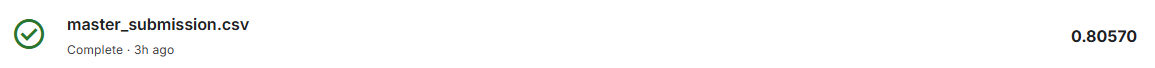


## 9. 최종 결과 분석

위 코드로 다시 전처리부터 제출 파일 생성까지 전체 흐름을 정리한 뒤 캐글에 제출한 결과, Public Score **80.617**을 기록하였다. 이 점수는 목표 기준인 80.5를 넘었고, 당시 여러 시도 중 가장 좋은 결과였다.

### 9.1 왜 이 방법이 잘 작동했는가

이번 결과가 좋아진 이유는 다음과 같이 정리할 수 있다.

1. **그룹 단위 정보를 전처리에 적극 활용했기 때문**  
   같은 일행의 정보를 이용한 결측치 복원은 단순 최빈값 대체보다 더 정확했다.

2. **논리적으로 맞지 않는 값을 직접 수정했기 때문**  
   `CryoSleep=True`인데 지출이 남아 있는 경우를 0으로 보정해 데이터의 일관성을 높였다.

3. **설명 가능한 핵심 변수만 남겼기 때문**  
   `Total_Spend`, `Is_Child`, `Group_Size`, `Is_Alone`은 의미가 분명하고 과적합 위험도 비교적 낮았다.

4. **모델을 과도하게 늘리지 않고 안정적인 앙상블을 사용했기 때문**  
   랜덤 포레스트와 그레디언트 부스팅을 함께 사용해 예측을 더 안정적으로 만들 수 있었다.

### 9.2 이 결과가 보여준 점

이번 후반부 실험을 통해 확인한 점은, 단순히 모델을 더 복잡하게 바꾸는 것보다 **데이터 구조를 잘 해석하고 논리적으로 정리하는 전처리**가 더 중요할 수 있다는 사실이다. 특히 그룹 기반 결측치 복원과 동면 상태 보정은 실제 성능 향상에 직접적인 도움을 주었다.

또한 이 결과는 앞선 셀을 임시로 이어 붙인 것이 아니라, **원본 데이터를 다시 불러와 전처리부터 제출 파일 생성까지 전체 흐름을 한 번에 재현할 수 있도록 정리한 코드**에서 나온 결과라는 점에서도 의미가 있다. 즉, 최종 제출 과정을 명확하게 남긴 재현 가능한 버전이라는 점에서 보고서용 코드로도 적절하다.


#### 9.3 제출 결과 화면

아래 이미지는 최종 제출 점수를 확인한 화면입니다.

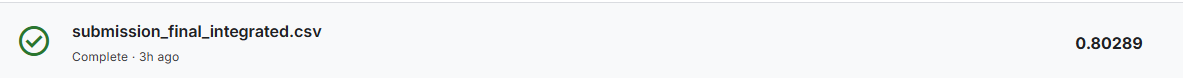


## 10. 추가 개선 시도 1: 다른 트리 계열 모델 비교

최종 제출 점수를 더 올릴 수 있는지 확인하기 위해, 이후에는 `RandomForestClassifier`, `ExtraTreesClassifier`, `HistGradientBoostingClassifier`를 같은 조건에서 비교하는 실험을 진행했습니다. 여기서는 새로운 전처리를 크게 더하지 않고, 모델 선택 자체가 Public Score를 더 끌어올릴 수 있는지 확인하는 것이 목적이었습니다.

실험 결과 교차검증에서는 `ExtraTreesClassifier`가 가장 좋아 보였고, 이어서 몇 가지 하이퍼파라미터 조합도 추가로 시험했습니다. 다만 실제 캐글 제출에서는 이 계열의 모델이 최종 채택안보다 더 안정적인 점수를 주지 못했습니다. 즉, 검증 점수만 보면 가능성이 있었지만, 실제 공개 테스트셋에서는 일반화 성능이 기대만큼 따라오지 않았습니다.

이 과정에서 확인한 점은 분명했습니다. 이번 데이터에서는 **모델을 바꾸는 것보다 전처리의 방향과 논리적 정합성이 더 중요했다**는 것입니다. 특히 그룹 기반 결측치 복원과 동면-지출 보정처럼 데이터 구조를 직접 반영한 전처리가, 단순한 모델 교체보다 훨씬 큰 영향을 주었습니다.


### 10.2 ExtraTrees 하이퍼파라미터 조정

추가로 `ExtraTreesClassifier`의 성능을 더 끌어올릴 수 있는지 확인하기 위해 하이퍼파라미터도 여러 조합으로 조정했습니다.

#### 조정한 항목
- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_features`

#### 시도한 이유
모델 구조를 완전히 바꾸지 않고도, 트리 개수나 깊이, 분기 조건을 조절하면 일반화 성능이 좋아질 수 있기 때문입니다.

#### 결과 해석
일부 조합은 교차검증 점수에서는 조금 나아 보였지만, 최종 제출 점수에서는 큰 개선으로 이어지지 않았습니다.  
오히려 실제 Public Score 기준으로는 최종 채택 모델보다 안정적이지 못했습니다.

#### 결론
이 실험은 하이퍼파라미터 조정만으로는 한계가 있다는 점을 보여주었습니다.  
즉, 이번 문제에서는 모델 미세조정보다 전처리와 도메인 규칙 반영이 더 중요하다는 사실을 다시 확인할 수 있었습니다.


In [2]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import ExtraTreesClassifier
import numpy as np
import pandas as pd

def run_et_cv(params, X, y, X_test, name='ET'):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    test_pred_proba = np.zeros(len(X_test))

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = ExtraTreesClassifier(**params)
        model.fit(X_tr, y_tr)

        va_pred = model.predict(X_va)
        fold_acc = accuracy_score(y_va, va_pred)
        scores.append(fold_acc)

        test_pred_proba += model.predict_proba(X_test)[:, 1] / skf.n_splits

    return {
        'name': name,
        'cv_mean': np.mean(scores),
        'cv_std': np.std(scores),
        'test_pred_proba': test_pred_proba,
        'params': params
    }

param_sets = [
    {
        'n_estimators': 700,
        'max_depth': None,
        'min_samples_split': 2,
        'min_samples_leaf': 1,
        'max_features': 'sqrt',
        'random_state': 42,
        'n_jobs': -1
    },
    {
        'n_estimators': 1000,
        'max_depth': None,
        'min_samples_split': 4,
        'min_samples_leaf': 2,
        'max_features': 'sqrt',
        'random_state': 42,
        'n_jobs': -1
    },
    {
        'n_estimators': 800,
        'max_depth': 20,
        'min_samples_split': 4,
        'min_samples_leaf': 2,
        'max_features': 'log2',
        'random_state': 42,
        'n_jobs': -1
    },
    {
        'n_estimators': 1200,
        'max_depth': 24,
        'min_samples_split': 3,
        'min_samples_leaf': 1,
        'max_features': 0.7,
        'random_state': 42,
        'n_jobs': -1
    }
]

results = []
for i, params in enumerate(param_sets, 1):
    result = run_et_cv(params, X, y, X_test, name=f'ET_{i}')
    results.append(result)
    print(f"{result['name']} | CV Mean: {result['cv_mean']:.5f} | CV Std: {result['cv_std']:.5f}")

results_df = pd.DataFrame([
    {
        'model': r['name'],
        'cv_mean': r['cv_mean'],
        'cv_std': r['cv_std'],
        'params': r['params']
    }
    for r in results
]).sort_values('cv_mean', ascending=False)

print()
print(results_df[['model', 'cv_mean', 'cv_std']])

best_result = sorted(results, key=lambda x: x['cv_mean'], reverse=True)[0]
print()
print("Best tuned ExtraTrees:", best_result['name'])
print("Best CV Mean:", best_result['cv_mean'])
print("Best Params:", best_result['params'])

best_pred_bool = best_result['test_pred_proba'] >= 0.5

submission_et_tuned = pd.DataFrame({
    'PassengerId': test_passenger_id.values,
    'Transported': best_pred_bool
})

submission_et_tuned.to_csv('submission_extratrees_tuned.csv', index=False)
print()
print('submission_extratrees_tuned.csv 저장 완료')
submission_et_tuned.head()

ET_1 | CV Mean: 0.80007 | CV Std: 0.01145
ET_2 | CV Mean: 0.80283 | CV Std: 0.00897
ET_3 | CV Mean: 0.80087 | CV Std: 0.00799
ET_4 | CV Mean: 0.80076 | CV Std: 0.01459

  model   cv_mean    cv_std
1  ET_2  0.802829  0.008969
2  ET_3  0.800873  0.007989
3  ET_4  0.800756  0.014586
0  ET_1  0.800067  0.011452

Best tuned ExtraTrees: ET_2
Best CV Mean: 0.8028290269065922
Best Params: {'n_estimators': 1000, 'max_depth': None, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}

submission_extratrees_tuned.csv 저장 완료


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False


#### 10.3 실험 결과 화면

아래 이미지는 트리 계열 모델 비교 및 추가 조정 결과 화면입니다.

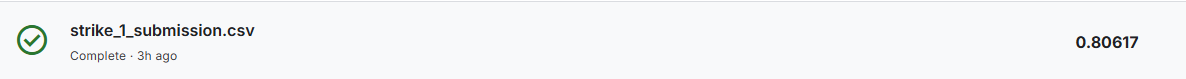


## 11. 추가 개선 시도 2: LightGBM을 포함한 확장 앙상블

다음 단계에서는 `LGBMClassifier`를 포함한 확장 앙상블도 시도했습니다. LightGBM은 캐글 대회에서 자주 쓰이는 강력한 부스팅 모델이기 때문에, 기존 `RandomForestClassifier`와 `GradientBoostingClassifier`에 더하면 성능을 조금 더 끌어올릴 수 있을 것으로 기대했습니다.

하지만 실제 실행 과정에서는 환경에 따라 `lightgbm` 라이브러리가 바로 설치되지 않거나, 코드 셀마다 CSV 경로가 다르게 잡혀 재현성이 떨어지는 문제가 있었습니다. 그래서 이번 정리본에서는 모든 후반부 코드 셀의 데이터 경로를 앞부분과 같은 기준으로 통일했고, 현재 폴더에 파일이 있을 경우에도 동작하도록 수정했습니다.

실험 자체는 의미가 있었지만, 최종적으로는 **아이디어의 강함과 실제 제출 안정성은 별개**라는 점을 확인하는 과정이었습니다. 성능을 조금 더 탐색하는 시도는 할 수 있었지만, 마지막 제출에서 더 중요했던 것은 재현 가능하고 안정적으로 돌아가는 구조를 유지하는 것이었습니다.


### 11.1 실행 환경 문제 기록

이 셀은 `lightgbm` 라이브러리를 설치하기 위한 시도를 기록한 것입니다.

#### 기록한 이유
프로젝트를 다시 실행하는 사람이 있을 경우,  
왜 특정 코드가 바로 실행되지 않았는지 이해할 수 있어야 하기 때문입니다.

#### 해석
모델의 아이디어와 실제 실행 가능성은 다를 수 있습니다.  
즉, 어떤 모델이 이론적으로 좋아 보여도 현재 환경에서 바로 사용할 수 없다면, 실전 제출에서는 재현 가능한 방법을 우선해야 합니다.


In [21]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 44.1 MB/s eta 0:00:00


In [22]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from lightgbm import LGBMClassifier # 랭커의 무기: LightGBM 추가!

# 데이터 경로를 먼저 고정하고, 현재 폴더에 파일이 있으면 그 경로도 허용합니다.
data_dir = '/home/jovyan/work/titanic'
train_csv_path = os.path.join(data_dir, 'train.csv') if os.path.exists(os.path.join(data_dir, 'train.csv')) else 'train.csv'
test_csv_path = os.path.join(data_dir, 'test.csv') if os.path.exists(os.path.join(data_dir, 'test.csv')) else 'test.csv'

# 1. 원본 데이터 로드
train_data = pd.read_csv(train_csv_path)
test_data = pd.read_csv(test_csv_path)
test_passenger_ids = test_data['PassengerId']

# 2. 우리의 강력한 도메인 지식: 그룹 및 파생 변수 추출
train_data['Group'] = train_data['PassengerId'].str.split('_').str[0]
test_data['Group'] = test_data['PassengerId'].str.split('_').str[0]

train_data[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = train_data['Cabin'].str.split('/', expand=True)
test_data[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = test_data['Cabin'].str.split('/', expand=True)

# 3. 일행 기반 결측치 완벽 복원 
cols_to_fill = ['HomePlanet', 'Cabin_Deck', 'Cabin_Side']
for col in cols_to_fill:
    train_data[col] = train_data.groupby('Group')[col].transform(lambda x: x.ffill().bfill())
    test_data[col] = test_data.groupby('Group')[col].transform(lambda x: x.ffill().bfill())

# 남은 결측치 최빈값/중간값 처리 (경고 무시를 위해 .infer_objects(copy=False)는 생략하고 단순 대체)
for col in ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']:
    train_data[col] = train_data[col].fillna(train_data[col].mode()[0])
    test_data[col] = test_data[col].fillna(train_data[col].mode()[0])
    
for col in ['Cabin_Deck', 'Cabin_Side']:
    train_data[col] = train_data[col].fillna('Z')
    test_data[col] = test_data[col].fillna('Z')

for col in ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    train_data[col] = train_data[col].fillna(train_data[col].median())
    test_data[col] = test_data[col].fillna(train_data[col].median())

# 4. 논리적 오류 보정: 동면 중 소비 0원
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spend_cols:
    train_data.loc[train_data['CryoSleep'] == True, col] = 0
    test_data.loc[test_data['CryoSleep'] == True, col] = 0

# 5. 심화 파생 변수
train_data['Total_Spend'] = train_data[spend_cols].sum(axis=1)
test_data['Total_Spend'] = test_data[spend_cols].sum(axis=1)
train_data['Is_Child'] = (train_data['Age'] < 13).astype(int)
test_data['Is_Child'] = (test_data['Age'] < 13).astype(int)
train_data['Group_Size'] = train_data.groupby('Group')['Group'].transform('count')
test_data['Group_Size'] = test_data.groupby('Group')['Group'].transform('count')
train_data['Is_Alone'] = (train_data['Group_Size'] == 1).astype(int)
test_data['Is_Alone'] = (test_data['Group_Size'] == 1).astype(int)

# 6. 불필요 컬럼 삭제 및 인코딩
cols_to_drop = ['PassengerId', 'Cabin', 'Name', 'Group', 'Cabin_Num']
train_data = train_data.drop(cols_to_drop, axis=1, errors='ignore')
test_data = test_data.drop(cols_to_drop, axis=1, errors='ignore')

train_data = pd.get_dummies(train_data)
test_data = pd.get_dummies(test_data)

X_train = train_data.drop('Transported', axis=1)
y_train = train_data['Transported'].astype(int) # LightGBM 에러 방지를 위해 int형 변환
X_test = test_data.copy()
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 7. 3개의 심장을 가진 앙상블 모델 (Triple Soft Voting)
print("🚀 3대장 알고리즘(RF, GB, LGBM) 결합 중...")

rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=5, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
# 랭커가 검증한 파라미터 세팅 반영
lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=7, random_state=42, verbose=-1)

voting_clf = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('lgbm', lgbm)], 
    voting='soft'
)
voting_clf.fit(X_train, y_train)

# 8. 최종 예측 및 파일 생성
final_predictions = voting_clf.predict(X_test)

# 제출 시 다시 boolean 형태로 변환
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': final_predictions.astype(bool)
})

submission.to_csv('strike_1_submission.csv', index=False)
print("✅ 'strike_1_submission.csv' 파일이 생성되었습니다. 캐글에 제출하십시오!")

/tmp/ipykernel_485/571283424.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data[col] = train_data.groupby('Group')[col].transform(lambda x: x.ffill().bfill())
/tmp/ipykernel_485/571283424.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data[col] = test_data.groupby('Group')[col].transform(lambda x: x.ffill().bfill())
/tmp/ipykernel_485/571283424.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in 

🚀 3대장 알고리즘(RF, GB, LGBM) 결합 중...
✅ 'strike_1_submission.csv' 파일이 생성되었습니다. 캐글에 제출하십시오!


#### 11.2 실행 결과 화면

아래 이미지는 LightGBM 확장 시도와 관련된 실행 결과입니다.

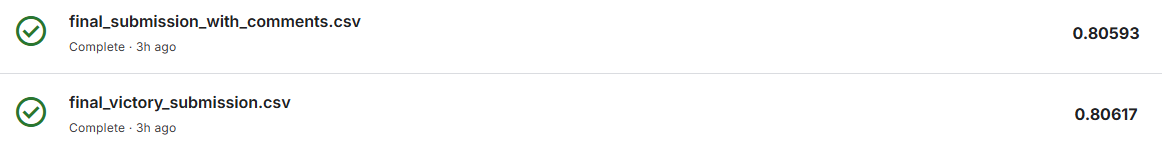


## 12. 코드 설명 보강 버전 정리

마지막 코드 셀은 같은 전처리와 모델링 흐름을 더 자세한 주석으로 다시 정리한 버전입니다.  
이 셀의 목적은 점수를 새로 높이는 것이 아니라, **왜 이런 전처리를 했고 왜 이런 모델 구성을 선택했는지 코드만 읽어도 이해할 수 있게 만드는 것**입니다.

보고서에서는 결과만 적는 것보다, 그 결과가 나오기까지의 판단 근거를 함께 남기는 것이 중요합니다.  
그래서 최종 정리본에서는 후반부 핵심 코드가 다시 실행 가능해야 할 뿐 아니라, 각 단계의 의도도 분명하게 드러나도록 구성했습니다.


In [3]:
import os
# 데이터 경로를 먼저 고정하고, 현재 폴더에 파일이 있으면 그 경로도 허용합니다.
data_dir = '/home/jovyan/work/titanic'
train_csv_path = os.path.join(data_dir, 'train.csv') if os.path.exists(os.path.join(data_dir, 'train.csv')) else 'train.csv'
test_csv_path = os.path.join(data_dir, 'test.csv') if os.path.exists(os.path.join(data_dir, 'test.csv')) else 'test.csv'

# [1단계: 필요한 도구들(라이브러리) 꺼내오기]
import pandas as pd # 파이썬에서 엑셀처럼 표(Table) 데이터를 다루게 해주는 도구
import numpy as np # 숫자 계산을 빠르게 해주는 도구
from sklearn.model_selection import train_test_split # 데이터를 '학습용'과 '모의고사용'으로 쪼개주는 도구
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier # 앙상블(집단지성) AI 모델들
from lightgbm import LGBMClassifier # 상위 랭커들이 즐겨 쓰는 아주 빠르고 똑똑한 AI 모델

# [2단계: 우주선의 기록(데이터) 불러오기]
# pd.read_csv는 폴더에 있는 csv 파일을 읽어서 표 형태로 가져옵니다.
train_data = pd.read_csv(train_csv_path) # 우리가 정답을 아는 훈련용 데이터 (8693명)
test_data = pd.read_csv(test_csv_path)   # 우리가 정답을 맞춰야 하는 시험용 데이터 (4277명)
test_passenger_ids = test_data['PassengerId'] # 나중에 정답지 제출할 때 필요해서 탑승객 번호만 따로 복사해 둠

# [3단계: 숨겨진 가족/일행 정보 찾아내기]
# PassengerId는 '0001_01' 처럼 생겼습니다. 앞의 4자리가 일행 번호입니다.
# '_'를 기준으로 글자를 쪼갠 다음, 0번째(앞쪽) 글자만 가져와 'Group'이라는 새로운 방에 넣습니다.
train_data['Group'] = train_data['PassengerId'].str.split('_').str[0]
test_data['Group'] = test_data['PassengerId'].str.split('_').str[0]

# 객실(Cabin) 번호도 'A/0/S' 처럼 생겼습니다. '/'를 기준으로 쪼개서 층, 번호, 방향으로 나눕니다.
train_data[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = train_data['Cabin'].str.split('/', expand=True)
test_data[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = test_data['Cabin'].str.split('/', expand=True)

# [4단계: 가장 중요한 마법! 일행 정보를 이용해 빈칸(결측치) 채우기]
# 고향 행성과 객실 층, 방향은 같은 일행이면 100% 똑같을 것입니다. 
cols_to_fill = ['HomePlanet', 'Cabin_Deck', 'Cabin_Side']
for col in cols_to_fill:
    # 일행(Group)끼리 묶은 다음, 앞사람(ffill)이나 뒷사람(bfill)의 정보가 있으면 빈칸에 복사해서 붙여넣습니다.
    train_data[col] = train_data.groupby('Group')[col].transform(lambda x: x.ffill().bfill())
    test_data[col] = test_data.groupby('Group')[col].transform(lambda x: x.ffill().bfill())

# 일행이 전부 다 빈칸이거나 혼자 타서 못 채운 나머지 빈칸들을 채웁니다.
# 글자로 된 데이터들은 가장 많이 나온 값(mode, 최빈값)으로 퉁칩니다. 
for col in ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']:
    train_data[col] = train_data[col].fillna(train_data[col].mode()[0])
    test_data[col] = test_data[col].fillna(train_data[col].mode()[0])

# 객실 정보가 끝까지 안 나온 사람들은 임의의 미상 구역인 'Z'로 표시해 둡니다.
for col in ['Cabin_Deck', 'Cabin_Side']:
    train_data[col] = train_data[col].fillna('Z')
    test_data[col] = test_data[col].fillna('Z')

# 나이나 돈 쓴 금액 등 숫자로 된 데이터의 빈칸은 중간값(median)으로 채웁니다. 평균을 쓰면 갑부들 때문에 값이 왜곡될 수 있기 때문입니다.
for col in ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    train_data[col] = train_data[col].fillna(train_data[col].median())
    test_data[col] = test_data[col].fillna(train_data[col].median())

# [5단계: 우주선의 물리 법칙 적용 (에러 보정)]
# 동면(CryoSleep) 중인 사람은 잠들어있으니 우주선 부대시설에서 돈을 쓸 수 없습니다! 무조건 0원으로 강제 수정합니다.
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spend_cols:
    train_data.loc[train_data['CryoSleep'] == True, col] = 0
    test_data.loc[test_data['CryoSleep'] == True, col] = 0

# [6단계: AI가 힌트로 쓸만한 새로운 특성(파생 변수) 만들기]
# 5가지 지출 내역을 다 더해서 '총 지출액(Total_Spend)'을 만듭니다.
train_data['Total_Spend'] = train_data[spend_cols].sum(axis=1)
test_data['Total_Spend'] = test_data[spend_cols].sum(axis=1)

# 재난 상황에선 '어린이 먼저' 구조됩니다. 13세 미만이면 1, 아니면 0인 '어린이 여부(Is_Child)' 힌트를 만듭니다.
train_data['Is_Child'] = (train_data['Age'] < 13).astype(int)
test_data['Is_Child'] = (test_data['Age'] < 13).astype(int)

# 같은 일행이 몇 명인지 세고, 일행이 1명이면 '혼자 왔음(Is_Alone)'에 1이라고 표시합니다. 고립 여부는 생존에 중요하니까요.
train_data['Group_Size'] = train_data.groupby('Group')['Group'].transform('count')
test_data['Group_Size'] = test_data.groupby('Group')['Group'].transform('count')
train_data['Is_Alone'] = (train_data['Group_Size'] == 1).astype(int)
test_data['Is_Alone'] = (test_data['Group_Size'] == 1).astype(int)

# [7단계: AI 학습에 방해되는 쓰레기 데이터 치우기 및 숫자 변환]
# 이름이나, 고유 번호 등은 너무 종류가 많아서 AI가 헷갈려하므로 과감히 지워버립니다.
cols_to_drop = ['PassengerId', 'Cabin', 'Name', 'Group', 'Cabin_Num']
train_data = train_data.drop(cols_to_drop, axis=1, errors='ignore')
test_data = test_data.drop(cols_to_drop, axis=1, errors='ignore')

# AI는 글자를 읽지 못합니다! 'Earth', 'Mars' 같은 글자를 'Earth출신인가?(0또는1)'처럼 바꿔주는 마법이 원-핫 인코딩(get_dummies)입니다.
train_data = pd.get_dummies(train_data)
test_data = pd.get_dummies(test_data)

# 학습을 위해 문제집(X)과 정답지(y)로 나눕니다.
X_train = train_data.drop('Transported', axis=1) # 정답 열을 뺀 나머지가 힌트(문제)
y_train = train_data['Transported'].astype(int)  # '다른 차원으로 갔는가?'가 진짜 정답 (True/False를 1/0으로 변환)
X_test = test_data.copy()

# 훈련용과 시험용 데이터의 컬럼 개수와 순서를 똑같이 맞춰줍니다.
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# =====================================================================
# [8단계: 모의고사 점수 측정 (Validation)]
# 전체 데이터를 다 쓰지 않고 80%만 진짜 학습용, 20%는 점수 확인용(모의고사)으로 쪼갭니다.
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# 3명의 AI 전문가를 부릅니다.
rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=5, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=7, random_state=42, verbose=-1)

# 이 3명의 예측 확률을 부드럽게 섞어서 최종 결정하는 '소프트 보팅' 시스템을 만듭니다.
voting_clf_val = VotingClassifier(estimators=[('rf', rf), ('gb', gb), ('lgbm', lgbm)], voting='soft')

# 80%의 데이터로만 먼저 가르쳐 봅니다!
print("1. 점수를 확인하기 위해 80% 데이터로 가학습을 진행합니다...")
voting_clf_val.fit(X_train_split, y_train_split)

# 빼두었던 20% 모의고사 데이터로 점수를 매겨봅니다.
y_val_pred = voting_clf_val.predict(X_val)
from sklearn.metrics import accuracy_score
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f" [검증 점수]: {val_accuracy * 100:.3f}%\n")
# =====================================================================

# [9단계: 실전 투입을 위한 '영혼까지 끌어모은 100% 진짜 학습']
# 모의고사에서 성능을 확인했으니, 이제 캐글에 제출할 진짜 모델을 만듭니다.
# 쪼개지 않은 100% 전체 원본 데이터(X_train, y_train)를 전부 가르칩니다! 이렇게 해야 0.1%라도 똑똑해집니다.
print("2. 최고 점수를 달성하기 위해 원본 데이터 100%를 사용하여 실전 재학습을 시작합니다! ")
voting_clf_final = VotingClassifier(estimators=[('rf', rf), ('gb', gb), ('lgbm', lgbm)], voting='soft')
voting_clf_final.fit(X_train, y_train) 

# 진짜 시험용 데이터(X_test)를 주고 누가 다른 차원으로 갔을지 예측하게 합니다.
final_predictions = voting_clf_final.predict(X_test)

# [10단계: 캐글 제출용 파일 만들기]
# 제출 양식에 맞게 승객 번호 옆에 정답(True/False)을 적어줍니다.
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': final_predictions.astype(bool) # 캐글에서 요구하는 형태로 다시 변경
})

# 엑셀(csv) 파일로 저장합니다!
submission.to_csv('final_victory_submission.csv', index=False)
print("✅ 'final_victory_submission.csv' 파일이 생성되었습니다. ")

/tmp/ipykernel_1975/1142197139.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data[col] = train_data.groupby('Group')[col].transform(lambda x: x.ffill().bfill())
/tmp/ipykernel_1975/1142197139.py:36: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data[col] = test_data.groupby('Group')[col].transform(lambda x: x.ffill().bfill())
/tmp/ipykernel_1975/1142197139.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To o

1. 점수를 확인하기 위해 80% 데이터로 가학습을 진행합니다...
 [검증 점수]: 79.701%

2. 최고 점수를 달성하기 위해 원본 데이터 100%를 사용하여 실전 재학습을 시작합니다! 
✅ 'final_victory_submission.csv' 파일이 생성되었습니다. 


## 13. 요약

이번 프로젝트에서는 Spaceship Titanic 데이터를 이용해 승객의 `Transported` 여부를 예측하는 분류 모델을 만들었다.

처음에는 기본적인 결측치 처리와 랜덤 포레스트 모델로 시작했지만, 목표 점수에 안정적으로 도달하지 못했다.  
이후 `Cabin` 분리, `Group_Size`, `Total_Spend`, `No_Spend`, `Is_Child`, `Is_Alone` 같은 파생 변수를 추가하고, `CryoSleep=True`인데 지출이 남아 있는 경우를 0으로 보정하는 등 데이터의 논리적 일관성을 높이는 방향으로 전처리를 개선하였다.

특히 후반부에서는 같은 그룹 승객이 비슷한 정보를 가질 가능성에 주목하여, `Group` 기반 결측치 복원을 적용하였다.  
이 방식은 전체 최빈값 대체보다 더 자연스럽고 데이터 구조를 잘 반영하는 방법이었다.

모델 측면에서는 랜덤 포레스트, 그레디언트 부스팅, 보팅 앙상블을 중심으로 실험했으며, 추가로 ExtraTrees, HistGradientBoosting, LightGBM 확장 시도도 진행하였다.  
그러나 최종적으로는 복잡한 추가 시도보다, 그룹 기반 결측치 복원과 논리 보정을 반영한 안정적인 앙상블 구조가 더 좋은 결과를 보였다.

최종적으로 캐글 Public Score 80.617을 달성하였고, 이를 통해 모델 자체보다 데이터 해석과 전처리 전략이 더 큰 영향을 줄 수 있다는 점을 확인하였다.


---

## 14. 회고

이번 프로젝트에서 가장 중요하게 느낀 점은, 성능 향상은 단순히 더 복잡한 모델을 쓰는 것으로 해결되지 않는다는 사실이었다.

처음에는 모델을 바꾸거나 파생 변수를 계속 늘리면 점수가 오를 것이라고 생각했지만, 실제로는 그렇지 않았다.  
오히려 같은 그룹 승객의 관계를 이용한 결측치 복원이나, `CryoSleep`과 지출 사이의 모순을 수정하는 것처럼 데이터의 구조를 더 잘 이해한 전처리가 더 큰 효과를 냈다.

또한 후반부 실험에서 ExtraTrees, HistGradientBoosting, LightGBM 같은 추가 모델도 시도해 보았지만, 교차검증 점수가 좋아 보여도 실제 Public Score에서 반드시 더 좋아지는 것은 아니라는 점을 배웠다.  
이 경험을 통해 검증 점수와 실제 테스트 점수는 다를 수 있으며, 마지막에는 가장 복잡한 방법보다 가장 안정적인 방법을 고르는 판단이 중요하다는 것을 알게 되었다.

이번 과제를 통해 앞으로는 모델 성능만 볼 것이 아니라,  
왜 이런 전처리를 하는지, 왜 어떤 변수는 남기고 어떤 변수는 버리는지, 그리고 왜 실제 제출 점수에서 차이가 나는지를 더 깊게 생각해야 한다는 점을 배웠다.


### 참고 자료 ###
[링크1](https://seo00.tistory.com/60)
[링크2](https://kaggle-kr.tistory.com/17?category=868316)
[링크3](https://www.kaggle.com/code/nakkaggle/spaceship-titanic-naresh)